<a href="https://colab.research.google.com/github/FurkanAlpGurakan/brain-tumor-detector-app/blob/main/Brain_Tumor_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor Detection


## Modelleri İmport Et


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Input, ZeroPadding2D, BatchNormalization, Activation, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import shuffle
import cv2
import imutils
import numpy as np
import matplotlib.pyplot as plt
import time
from os import listdir

%matplotlib inline

## Veri Hazırlama ve Ön İşleme


Görüntünün sadece beyni içeren kısmını kırpmak için, beynin en üst, en alt, en sol ve en sağ noktalarını bulmak üzere bir kırpma tekniği kullandım.

In [ ]:
def crop_brain_contour(image, plot=False):

    #import imutils
    #import cv2
    #from matplotlib import pyplot as plt

    # Görüntüyü gri tonlamaya dönüştürün ve hafifçe bulanıklaştırın
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key=cv2.contourArea)


    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])

    # dört uç noktayı (sol, sağ, üst, alt) kullanarak orijinal görüntüden yeni görüntüyü kırptım
    new_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]

    if plot:
        plt.figure()

        plt.subplot(1, 2, 1)
        plt.imshow(image)

        plt.tick_params(axis='both', which='both',
                        top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)

        plt.title('Original Image')

        plt.subplot(1, 2, 2)
        plt.imshow(new_image)

        plt.tick_params(axis='both', which='both',
                        top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)

        plt.title('Cropped Image')

        plt.show()

    return new_image

Bir örnek üzerinden ne yaptığımı gösterdim:

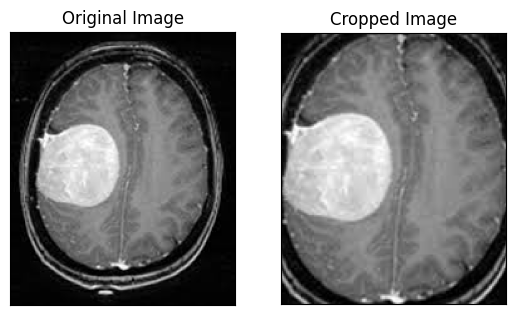

In [ ]:
ex_img = cv2.imread('drive/MyDrive/data/yes/Y1.jpg')
ex_new_img = crop_brain_contour(ex_img, True)

### Verileri yükleyin:

Aşağıdaki fonksiyon iki argüman alır. İlk argüman, 'yes' ve 'no' adlı klasörlerin görüntü verilerini içeren dizin yollarının bir listesidir. İkinci argüman ise görüntü boyutudur. Bu fonksiyon, her iki dizindeki tüm görüntüler için şu işlemleri gerçekleştirir:

Görüntüyü okur.<br>
Görüntünün yalnızca beyni temsil eden kısmını kırpar.<br>
Görüntüyü yeniden boyutlandırır (çünkü veri kümesindeki görüntüler farklı boyutlarda gelir; yani genişlik, yükseklik ve kanal sayısı farklı olabilir). Bu yüzden, tüm görüntülerin boyutlarını (240, 240, 3) olacak şekilde ayarlarız ki sinir ağına giriş olarak verilebilsin.<br>
Normalizasyon uygular; çünkü piksel değerlerinin 0-1 aralığında ölçeklenmesini isteriz<br>
Görüntüyü X listesine ve etiketini y listesine ekler.
Sonrasında:

X ve y shuffle (karıştırma) işlemi yapılır. Çünkü veriler sıralıdır (yani dizilerde bir sınıfa ait görüntüler bir kısımda, diğer sınıfa ait görüntüler başka bir kısımda yer alır ve bunu istemeyiz).<br>
Son olarak:
X ve y listelerini döndürür.

In [ ]:
def load_data(dir_list, image_size):
    """
    Read images, resize and normalize them.
    Arguments:
        dir_list: list of strings representing file directories.
    Returns:
        X: A numpy array with shape = (#_examples, image_width, image_height, #_channels)
        y: A numpy array with shape = (#_examples, 1)
    """

    # tüm görselleri bir dizine yükle
    X = []
    y = []
    image_width, image_height = image_size

    for directory in dir_list:
        for filename in listdir(directory):
            # resmi yükle
            image = cv2.imread(directory + '/' + filename)
            # beyni kırpın ve görüntünün gereksiz kalan kısmını göz ardı edin
            image = crop_brain_contour(image, plot=False)
            # resize image
            image = cv2.resize(image, dsize=(image_width, image_height), interpolation=cv2.INTER_CUBIC)
            # resmi yeniden boyutlandır
            image = image / 255.
            # resmi numpy dizisine dönüştürün ve onu X'e ekle
            X.append(image)
            # eğer görüntü varsa hedef diziye 1 değerini ekleyin
            #, 'evet' adlı klasördedir, aksi halde 0 ekleyin.
            if directory[-3:] == 'yes':
                y.append([1])
            else:
                y.append([0])

    X = np.array(X)
    y = np.array(y)

    # Verileri karıştır
    X, y = shuffle(X, y)

    print(f'Number of examples is: {len(X)}')
    print(f'X shape is: {X.shape}')
    print(f'y shape is: {y.shape}')

    return X, y

Daha önce veri artırma tekniği ile zenginleştirdiğimiz verileri yükleyin. <br>
Not: zenginleştirilmiş veri dizini yalnızca yeni oluşturulan görüntüleri değil, aynı zamanda orijinal görüntüleri de içerir.

In [ ]:
augmented_path = 'drive/MyDrive/data/augmented data/'

# artırılmış veriler (evet ve hayır) hem orijinali hem de yeni oluşturulan örnekleri içerir
augmented_yes = augmented_path + 'yes'
augmented_no = augmented_path + 'no'

IMG_WIDTH, IMG_HEIGHT = (240, 240)

X, y = load_data([augmented_yes, augmented_no], (IMG_WIDTH, IMG_HEIGHT))

Number of examples is: 2065
X shape is: (2065, 240, 240, 3)
y shape is: (2065, 1)


Elimizde 2065 görüntü var. Her görüntü (240, 240)=(image_width, image_height) şekline sahiptir.

Örnek resimleri görselleştirdim:

In [ ]:
def plot_sample_images(X, y, n=50):
    """
    Plots n sample images for both values of y (labels).
    Arguments:
        X: A numpy array with shape = (#_examples, image_width, image_height, #_channels)
        y: A numpy array with shape = (#_examples, 1)
    """

    for label in [0,1]:

        images = X[np.argwhere(y == label)]
        n_images = images[:n]

        columns_n = 10
        rows_n = int(n/ columns_n)

        plt.figure(figsize=(20, 10))

        i = 1
        for image in n_images:
            plt.subplot(rows_n, columns_n, i)
            plt.imshow(image[0])

            plt.tick_params(axis='both', which='both',
                            top=False, bottom=False, left=False, right=False,
                           labelbottom=False, labeltop=False, labelleft=False, labelright=False)

            i += 1

        label_to_str = lambda label: "Yes" if label == 1 else "No"
        plt.suptitle(f"Brain Tumor: {label_to_str(label)}")
        plt.show()

In [ ]:
plot_sample_images(X, y)


X ve y'yi eğitim, doğrulama (geliştirme) ve test setlerine ayır.

In [ ]:
def split_data(X, y, test_size=0.2):

    """
    Splits data into training, development and test sets.
    Arguments:
        X: A numpy array with shape = (#_examples, image_width, image_height, #_channels)
        y: A numpy array with shape = (#_examples, 1)
    Returns:
        X_train: A numpy array with shape = (#_train_examples, image_width, image_height, #_channels)
        y_train: A numpy array with shape = (#_train_examples, 1)
        X_val: A numpy array with shape = (#_val_examples, image_width, image_height, #_channels)
        y_val: A numpy array with shape = (#_val_examples, 1)
        X_test: A numpy array with shape = (#_test_examples, image_width, image_height, #_channels)
        y_test: A numpy array with shape = (#_test_examples, 1)
    """

    X_train, X_test_val, y_train, y_test_val = train_test_split(X, y, test_size=test_size)
    X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val, test_size=0.5)

    return X_train, y_train, X_val, y_val, X_test, y_test

 1.Verilerin %70'i eğitim için. <br>
 2.Verilerin %15'i doğrulama için. <br>
 3.Verilerin %15'i test için.

In [ ]:
X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y, test_size=0.3)

In [ ]:
print ("number of training examples = " + str(X_train.shape[0]))
print ("number of development examples = " + str(X_val.shape[0]))
print ("number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(y_train.shape))
print ("X_val (dev) shape: " + str(X_val.shape))
print ("Y_val (dev) shape: " + str(y_val.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(y_test.shape))

number of training examples = 1445
number of development examples = 310
number of test examples = 310
X_train shape: (1445, 240, 240, 3)
Y_train shape: (1445, 1)
X_val (dev) shape: (310, 240, 240, 3)
Y_val (dev) shape: (310, 1)
X_test shape: (310, 240, 240, 3)
Y_test shape: (310, 1)


Bazı yardımcı fonksiyonlar:

In [ ]:

def hms_string(sec_elapsed):
    h = int(sec_elapsed / (60 * 60))
    m = int((sec_elapsed % (60 * 60)) / 60)
    s = sec_elapsed % 60
    return f"{h}:{m}:{round(s,1)}"

In [ ]:
def compute_f1_score(y_true, prob):

    y_pred = np.where(prob > 0.5, 1, 0)

    score = f1_score(y_true, y_pred)

    return score

# Modeli oluşturun







In [ ]:
def build_model(input_shape):
    """
    Arugments:
        input_shape: A tuple representing the shape of the input of the model. shape=(image_width, image_height, #_channels)
    Returns:
        model: A Model object.
    """
    # Giriş yer tutucusunu input_shape şekliyle tensör olarak tanımlayın.
    X_input = Input(input_shape) # shape=(?, 240, 240, 3)

    # Zero-Padding: X_input'un kenarlığını sıfırlarla doldurur
    X = ZeroPadding2D((2, 2))(X_input) # shape=(?, 244, 244, 3)

    X = Conv2D(32, (7, 7), strides = (1, 1), name = 'conv0')(X)
    X = BatchNormalization(axis = 3, name = 'bn0')(X)
    X = Activation('relu')(X) # shape=(?, 238, 238, 32)


    X = MaxPooling2D((4, 4), name='max_pool0')(X) # shape=(?, 59, 59, 32)

    X = MaxPooling2D((4, 4), name='max_pool1')(X) # shape=(?, 14, 14, 32)

    X = Flatten()(X) # shape=(?, 6272)
    X = Dense(1, activation='sigmoid', name='fc')(X) # shape=(?, 1)


    model = Model(inputs = X_input, outputs = X, name='BrainDetectionModel')

    return model

Görüntü şeklini tanımladım:

In [ ]:
IMG_SHAPE = (IMG_WIDTH, IMG_HEIGHT, 3)

In [ ]:
model = build_model(IMG_SHAPE)

In [ ]:
model.summary()

Model: "BrainDetectionModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv0 (Conv2D)                  │ (None, 238, 238, 32)   │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn0 (BatchNormalization)        │ (None, 238, 238, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 238, 238, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool0 (MaxPooling2D)        │ (None, 59, 59, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,073 (43.25 KB)

 Non-trainable params: 64 (256.00 B)

Modeli derledim:

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
log_file_name = f'brain_tumor_detection_cnn_{int(time.time())}'
tensorboard = TensorBoard(log_dir=f'logs/{log_file_name}')

In [ ]:
# validation ve accuracy (geliştirme) doğruluğunu içerecek benzersiz dosya adı
filepath="cnn-parameters-improvement-{epoch:02d}-{val_accuracy:.2f}"
# modeli şu ana kadar en iyi doğrulama (geliştirme) doğruluğuna sahip olarak kaydedin
checkpoint = ModelCheckpoint("drive/MyDrive/data/models/{}.keras".format(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max'))

## Modeli eğitimi

In [ ]:
start_time = time.time()

model.fit(x=X_train, y=y_train, batch_size=32, epochs=10, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 0.5830 - loss: 0.9087 - val_accuracy: 0.6484 - val_loss: 0.6511
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7343 - loss: 0.5431 - val_accuracy: 0.6903 - val_loss: 0.6051
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7778 - loss: 0.4477 - val_accuracy: 0.6903 - val_loss: 0.5737
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8070 - loss: 0.4294 - val_accuracy: 0.7903 - val_loss: 0.5051
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8310 - loss: 0.3866 - val_accuracy: 0.8226 - val_loss: 0.4550
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8564 - loss: 0.3332 - val_accuracy: 0.8484 - val_loss: 0.4076
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9000 - loss: 0.2667 - val_accuracy: 0.6129 - val_loss: 0.6934
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8594 - loss: 0.3234 - val_accuracy: 0.8548 -

Birkaç defa daha çalıştıralım:

In [ ]:
start_time = time.time()

model.fit(x=X_train, y=y_train, batch_size=32, epochs=3, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9082 - loss: 0.2289 - val_accuracy: 0.8677 - val_loss: 0.3341
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9270 - loss: 0.2010 - val_accuracy: 0.7903 - val_loss: 0.4861
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9427 - loss: 0.1727 - val_accuracy: 0.8903 - val_loss: 0.2819
Elapsed time: 0:0:13.1


In [ ]:
start_time = time.time()

model.fit(x=X_train, y=y_train, batch_size=32, epochs=3, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9572 - loss: 0.1458 - val_accuracy: 0.8839 - val_loss: 0.2951
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9543 - loss: 0.1486 - val_accuracy: 0.8194 - val_loss: 0.4263
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9307 - loss: 0.1786 - val_accuracy: 0.8839 - val_loss: 0.2826
Elapsed time: 0:0:10.7


In [ ]:
start_time = time.time()

model.fit(x=X_train, y=y_train, batch_size=32, epochs=3, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9396 - loss: 0.1500 - val_accuracy: 0.8968 - val_loss: 0.2454
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9462 - loss: 0.1371 - val_accuracy: 0.8871 - val_loss: 0.2832
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9461 - loss: 0.1396 - val_accuracy: 0.8839 - val_loss: 0.2871
Elapsed time: 0:0:12.5


In [ ]:
start_time = time.time()

model.fit(x=X_train, y=y_train, batch_size=32, epochs=5, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

Epoch 1/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9642 - loss: 0.1196 - val_accuracy: 0.8581 - val_loss: 0.3569
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9708 - loss: 0.1022 - val_accuracy: 0.9032 - val_loss: 0.2522
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9663 - loss: 0.1208 - val_accuracy: 0.8871 - val_loss: 0.2910
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9805 - loss: 0.0886 - val_accuracy: 0.8968 - val_loss: 0.2635
Epoch 5/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9885 - loss: 0.0721 - val_accuracy: 0.8968 - val_loss: 0.2348
Elapsed time: 0:0:17.6


In [ ]:
history = model.history.history

In [ ]:
for key in history.keys():
    print(key)

accuracy
loss
val_accuracy
val_loss


# Kayıp ve Doğruluk verileri





In [ ]:
def plot_metrics(history):

    train_loss = history['loss']
    val_loss = history['val_loss']
    train_acc = history['accuracy']
    val_acc = history['val_accuracy']

    # Loss
    plt.figure()
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

    # Accuracy
    plt.figure()
    plt.plot(train_acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()
    plt.show()

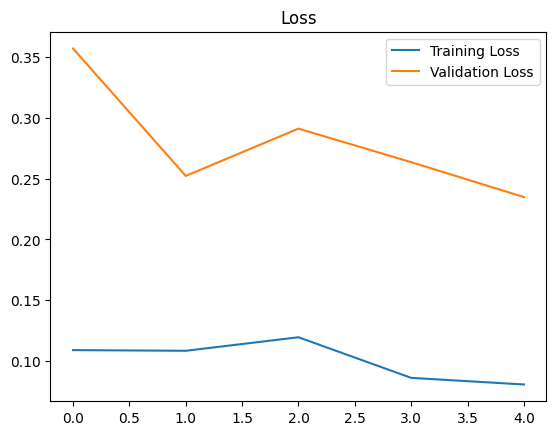

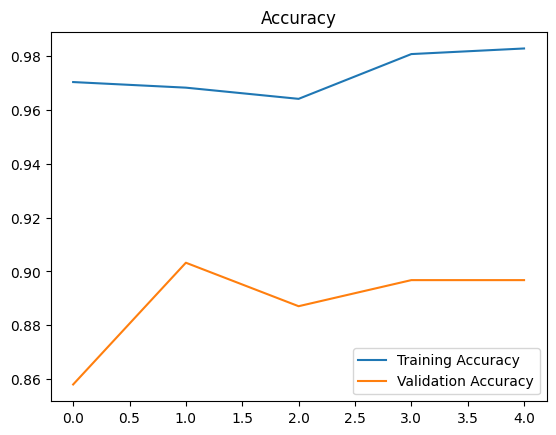

In [ ]:
plot_metrics(history)

#Sonuçlar

En iyi modeli (en iyi doğrulama doğruluğuna sahip olan) deneyelim:

### En iyi modeli yükleyelim

In [ ]:
best_model = load_model(filepath='/content/drive/MyDrive/data/models/cnn-parameters-improvement-05-0.90.keras')

In [ ]:
best_model.metrics_names

['loss', 'compile_metrics']

Test verileri üzerinde en iyi modeli değerlendirelim:

In [ ]:
loss, acc = best_model.evaluate(x=X_test, y=y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.9049 - loss: 0.2261


# Test verilerinde en iyi modelin doğruluğu:

In [ ]:
print (f"Test Loss = {loss}")
print (f"Test Accuracy = {acc}")

Test Loss = 0.19770210981369019
Test Accuracy = 0.9193548560142517


# Test verileri üzerinde en iyi model için F1 puanını belirlyelim:

In [ ]:
y_test_prob = best_model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step


In [ ]:
f1score = compute_f1_score(y_test, y_test_prob)
print(f"F1 score: {f1score}")

F1 score: 0.9271137026239067


Doğrulama verileri üzerinde f1 puanını da bulalım:

In [ ]:
y_val_prob = best_model.predict(X_val)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [ ]:
f1score_val = compute_f1_score(y_val, y_val_prob)
print(f"F1 score: {f1score_val}")

F1 score: 0.8974358974358975


### Sonuçların Yorumlanması

Olumlu ve olumsuz örneklerin yüzdeleri:

In [ ]:
def data_percentage(y):

    m=len(y)
    n_positive = np.sum(y)
    n_negative = m - n_positive

    pos_prec = (n_positive* 100.0)/ m
    neg_prec = (n_negative* 100.0)/ m

    print(f"Number of examples: {m}")
    print(f"Percentage of positive examples: {pos_prec}%, number of pos examples: {n_positive}")
    print(f"Percentage of negative examples: {neg_prec}%, number of neg examples: {n_negative}")



In [ ]:
# tüm veriler
data_percentage(y)

Number of examples: 2065
Percentage of positive examples: 52.54237288135593%, number of pos examples: 1085
Percentage of negative examples: 47.45762711864407%, number of neg examples: 980


In [ ]:
print("Training Data:")
data_percentage(y_train)
print("Validation Data:")
data_percentage(y_val)
print("Testing Data:")
data_percentage(y_test)

Training Data:
Number of examples: 1445
Percentage of positive examples: 51.97231833910035%, number of pos examples: 751
Percentage of negative examples: 48.02768166089965%, number of neg examples: 694
Validation Data:
Number of examples: 310
Percentage of positive examples: 51.29032258064516%, number of pos examples: 159
Percentage of negative examples: 48.70967741935484%, number of neg examples: 151
Testing Data:
Number of examples: 310
Percentage of positive examples: 56.45161290322581%, number of pos examples: 175
Percentage of negative examples: 43.54838709677419%, number of neg examples: 135


# Conclusion:

#### Now, the model detects brain tumor with:<br>
**88.7%** accuracy on the **test set**.<br>
**0.88** f1 score on the **test set**.<br>
These resutls are very good considering that the data is balanced.

**Performance Table:**

| <!-- -->  | Validation set | Test set |
| --------- | -------------- | -------- |
| Accuracy  | 91%            | 89%      |
| F1 score  | 0.91           | 0.88     |